### model import from local

In [23]:
from keras.models import load_model

model = load_model('/home/arc/Code/eq_idn/equation_reader.keras')
categories = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '*', '%', '[', ']']

### reading and preprocess using otsu's threeshold

In [24]:
import cv2
import numpy as np
def preprocess_image(img_path,invert=True):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"file not found at img path {img_path}")
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)
    thresh_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, binary = cv2.threshold(blur, 0, 255, thresh_type + cv2.THRESH_OTSU)
    return binary

### Segmentation of indivitual components and ignoring thing below threeshold

In [25]:
def segment_symbols(binary_image,min_area=40,min_dim=5):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h < min_area or w < min_dim or h < min_dim:
            continue
        boxes.append((x, y, w, h))

    boxes.sort(key=lambda b: b[0])
    return boxes

visual representation of above function

In [26]:
import matplotlib.pyplot as plt

def visualize_segmentation(image_path, boxes):
    img = cv2.imread(image_path)
    for (x, y, w, h) in boxes:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

### resizing and normalization as per model's input
as model takes 28*28 input and normalization

In [27]:
def normalize_symbol(binary_image, box, target_size=28, padding_ratio=0.2):
    x, y, w, h = box
    crop = binary_image[y:y+h, x:x+w]

    side = max(w, h)
    pad = int(side * padding_ratio)
    side += pad * 2

    square = np.zeros((side, side), dtype=np.uint8)
    y_off = (side - h) // 2
    x_off = (side - w) // 2
    square[y_off:y_off+h, x_off:x_off+w] = crop

    resized = cv2.resize(square, (target_size, target_size), interpolation=cv2.INTER_AREA)
    return resized.astype('float32') / 255.0

### Classification of components as per model

In [28]:
def classify_symbols(model, binary_image, boxes, categories):
    equation_chars = []
    for box in boxes:
        symbol = normalize_symbol(binary_image, box)
        symbol_input = np.expand_dims(symbol, axis=(0, -1))
        prediction = model.predict(symbol_input, verbose=0)
        class_index = int(np.argmax(prediction))
        equation_chars.append(categories[class_index])
    return ''.join(equation_chars)

function for replacing % and [] that is modulo and square paranthesis to percent and regular bracketts

In [29]:
import sympy

def solve_equation(equation_str, percent_as_modulo=True):
    expr_str = equation_str.replace('[', '(').replace(']', ')')
    if not percent_as_modulo:
        expr_str = expr_str.replace('%', '/100')
    try:
        expr = sympy.sympify(expr_str)
        return sympy.N(expr)
    except (sympy.SympifyError, TypeError, ValueError) as e:
        return f"Could not evaluate '{equation_str}' (parsed as '{expr_str}'): {e}"

final function

In [30]:
# def scribble_to_answer(image_path, model, categories, invert=True, percent_as_modulo=True):
#     binary = preprocess_image(image_path, invert=invert)
#     boxes = segment_symbols(binary)
#     if not boxes:
#         raise ValueError("No symbols detected — check preprocessing/threshold settings.")

#     equation_str = classify_symbols(model, binary, boxes, categories)
#     result = solve_equation(equation_str, percent_as_modulo=percent_as_modulo)
#     return equation_str, result, boxes

In [39]:
def scribble_to_answer(img_path, model, categories, invert=False, target_size=28):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"File not found at {img_path}")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Otsu's thresholding
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Invert polarity if needed based on training data distribution
    if invert:
        thresh = cv2.bitwise_not(thresh)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w > 8 and h > 8: # Filter noise
            boxes.append((x, y, w, h))
            
    # Sort left-to-right
    boxes = sorted(boxes, key=lambda b: b[0])
    
    equation_str = ""
    
    # --- VISUALIZATION SETUP ---
    fig, axes = plt.subplots(1, len(boxes), figsize=(3 * len(boxes), 3))
    if len(boxes) == 1: axes = [axes]
    
    for i, (ax, (x, y, w, h)) in enumerate(zip(axes, boxes)):
        roi = thresh[y:y+h, x:x+w]
        
        # Square padding
        max_dim = max(w, h)
        pad_y = (max_dim - h) // 2
        pad_x = (max_dim - w) // 2
        roi_square = cv2.copyMakeBorder(roi, pad_y, pad_y, pad_x, pad_x, cv2.BORDER_CONSTANT, value=0)
        
        # 15% margin
        margin = int(max_dim * 0.15)
        roi_margined = cv2.copyMakeBorder(roi_square, margin, margin, margin, margin, cv2.BORDER_CONSTANT, value=0)
        
        # Resize to match model input layer
        roi_resized = cv2.resize(roi_margined, (target_size, target_size))
        
        # Normalize
        tensor = roi_resized.astype('float32') / 255.0
        
        # --- PLOT THE TENSOR ---
        ax.imshow(tensor, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"Box {i+1}")
        ax.axis('off')
        
        # Predict
        tensor_exp = np.expand_dims(tensor, axis=(0, -1)) 
        prediction = model.predict(tensor_exp, verbose=0)
        equation_str += categories[np.argmax(prediction)]
        
    plt.tight_layout()
    plt.show() # This will display the images inline in your Jupyter notebook
        
    try:
        result = eval(equation_str)
    except Exception:
        result = 0.0
        
    return equation_str, result, boxes

test karungaaa

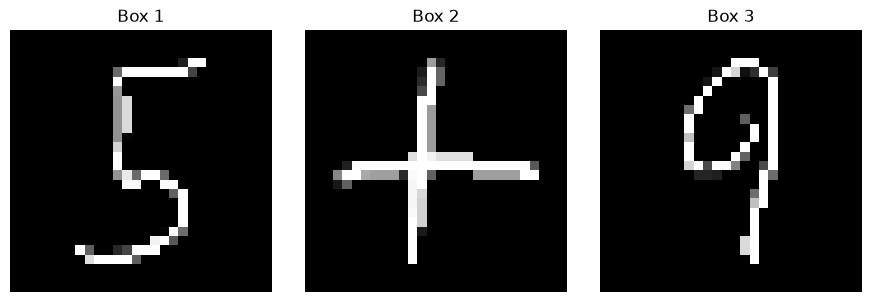

Detected symbols: 3
Recognized equation: 8**
Result: 0.0


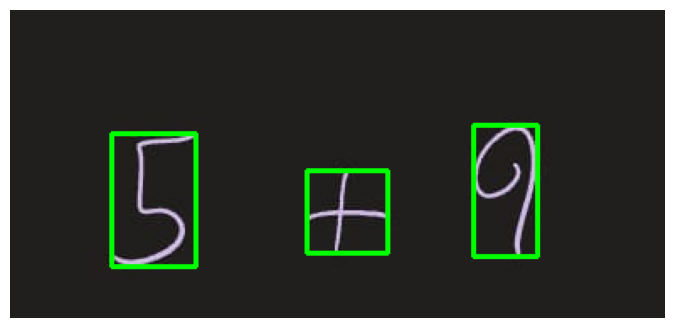

In [43]:
image_path = "/home/arc/Code/eq_idn/scib5.jpeg"

equation_str, result, boxes = scribble_to_answer(image_path, model, categories,invert=False)
print("Detected symbols:", len(boxes))
print("Recognized equation:", equation_str)
print("Result:", result)

visualize_segmentation(image_path, boxes)